In [2]:
import json 
import sys 
from pathlib import Path
fine_tune_predictions_file = "benchmark/predictions_finetune_parakeet_won.json"

In [3]:
with open(fine_tune_predictions_file,"r") as file:
    contents = json.load(file)

In [5]:
import numpy as np
from finetune.score import english_spelling_normalizer, score_wer

for content in contents:
    reference = content.get("reference")
    prediction = content.get("prediction")
    score = score_wer([reference], [prediction])
    content.update({"score":score})

/home/chandan/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
#filter by WER greater than 0.4
threshold = 0.4
filtered_contents = []
for content in contents:
    score = content.get("score")
    if score > threshold:
        filtered_contents.append(content)
print("Total Samples Above WER({}) : {} | Percentage : {}".format(threshold, len(filtered_contents), len(filtered_contents)/len(contents)))

Total Samples Above WER(0.4) : 2819 | Percentage : 0.1627410229765616


In [4]:
import random 
from IPython.display import Audio
import soundfile as sf

sample = contents[78]
reference_text = sample.get("reference")
predicted_text = sample.get("prediction")
audio_path = sample.get("audio_filepath")
score = sample.get("score")

print("Reference Text : {}".format(reference_text))
print("Predicted Text : {}".format(predicted_text))
print("Score : {}".format(score))
audio, sr = sf.read(audio_path)
Audio(audio_path)

Reference Text : why is there two swings
Predicted Text : why is there two strings
Score : None


In [6]:
import librosa 
import numpy as np 

if audio.ndim == 2:
    audio = np.mean(audio, axis=1)
else:
    audio = audio
modified_audio = librosa.effects.time_stretch(audio,rate=0.70)
modified_audio = modified_audio / np.max(np.abs(modified_audio))
Audio(modified_audio, rate=sr)

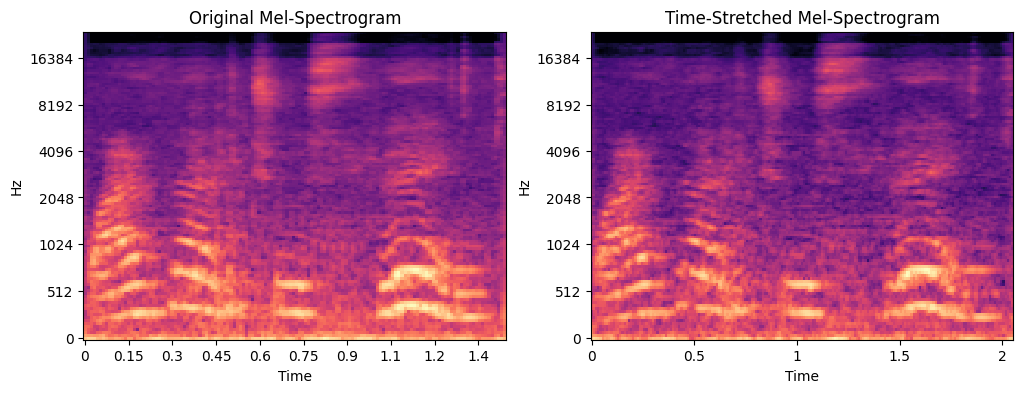

In [7]:
import matplotlib.pyplot as plt

# Original
S_orig = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
S_orig_db = librosa.power_to_db(S_orig, ref=np.max)

# Time-stretched
S_stretch = librosa.feature.melspectrogram(y=modified_audio, sr=sr, n_mels=128)
S_stretch_db = librosa.power_to_db(S_stretch, ref=np.max)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
librosa.display.specshow(S_orig_db, sr=sr, x_axis='time', y_axis='mel')
plt.title('Original Mel-Spectrogram')

plt.subplot(1,2,2)
librosa.display.specshow(S_stretch_db, sr=sr, x_axis='time', y_axis='mel')
plt.title('Time-Stretched Mel-Spectrogram')
plt.show()